# 05-The Mathematics of ANN (HNSW & IVF)

In Lesson 04, we engineered an in-memory vector database and uncovered the physics of **Recall Collapse**. We proved that relying on brute-force exact search—calculating the Cosine Similarity against every single record in a database—yields perfect results but forces a computational complexity of $\mathcal{O}(N \cdot D)$, where $N$ is the number of records and $D$ is the embedding dimension.

When scale reaches $10^7$ or $10^9$ records, brute-force search completely halts execution loops, triggering unacceptable latency in web services.

To bypass this computational bottleneck, modern vector search engines accept a micro-fraction of geometric error in exchange for massive sub-millisecond performance gains. This trade-off is governed by **Approximate Nearest Neighbor (ANN)** search.

We will dissect the mathematical and structural mechanics of the two dominant architectural paradigms powering modern vector indices: **Inverted File Indexing (IVF)** and **Hierarchical Navigable Small Worlds (HNSW)**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from sklearn.cluster import KMeans
import time

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Indexing Mathematics & ANN Simulation Environment Ready.")

✅ Indexing Mathematics & ANN Simulation Environment Ready.


## 1. Inverted File Indexing (IVF): Voronoi Space Quantization

The fundamental goal of an Inverted File (IVF) index is to prune the search space from $N$ vectors down to a tight, localized candidate subset. It achieves this by partitioning high-dimensional space into discrete geometric zones.

### The Mathematics of K-Means Clustering

Before any queries can be processed, the entire vector corpus $\mathcal{D}$ undergoes unsupervised spatial quantization using **K-Means Clustering**. The algorithm chooses a fixed hyperparameter $K$ (known as `nlist`) and iteratively computes a set of structural centroids $C = \{c_1, c_2, \dots, c_K\}$ to minimize the within-cluster sum of squares (inertia):

$$\arg\min_{C} \sum_{i=1}^{K} \sum_{v \in S_i} \|v - c_i\|^2$$

This process partitions $\mathbb{R}^D$ into a geometric structure known as a **Voronoi Diagram**. Every vector $v$ in the database is mapped to its nearest centroid $c_i$, establishing a collection of inverted lists (hence *Inverted File*) where each centroid points to a bucket of vectors clustered around it.

### Query Execution & The `nprobe` Parameter

When a user query vector $q$ arrives at runtime, the database avoids evaluating every individual vector record. Instead, it computes the distance between $q$ and all cluster centroids $c_i$. This initial operation costs a highly manageable $\mathcal{O}(K \cdot D)$.

The algorithm then selects the top $P$ closest centroids (where $P$ is the hyperparameter `nprobe`) and searches *only* the specific vector records stored inside those designated Voronoi cells.

* **Low `nprobe` (e.g., 1):** The search checks only the single closest Voronoi cell. Latency is extremely low, but if the query falls near the edge of a cell, the true nearest neighbors residing just across the boundary line are missed, causing a drop in **Recall Accuracy**.
* **High `nprobe` (approaching $K$):** The search expands to look inside many neighboring cells. Recall accuracy climbs toward $100\%$, but the computational complexity regresses back toward a costly linear scan.

## 2. Hierarchical Navigable Small Worlds (HNSW)

While IVF cuts down search spaces through clustering, **HNSW** structures the data into a multi-layered proximity graph. It is currently recognized as the gold standard for high-speed, high-dimensional semantic search.

### The Probabilistic Skip-List Pipeline

HNSW adapts the logic of a **Skip-List** data structure into graph topology. A skip-list chains elements across multiple layers. The lowest layer holds every single element sequentially. Each ascending layer skips elements with an exponentially decreasing probability, allowing a search routine to make massive spatial leaps before descending to fine-tune its path.

In HNSW, each layer is configured as a **Proximity Graph** where individual vector nodes are connected by geometric edges. The probability of an uploaded vector record climbing to a specific layer $l$ is calculated using a controlled decay multiplier $m_L$:

$$l = \lfloor -\ln(\text{uniform}(0,1)) \cdot m_L \rfloor$$

Layer 0 contains every single vector in the database. Layer 1 contains roughly $10\%$ of the vectors, and Layer 2 contains $1\%$.

### Traversal Mechanics

During a query event, the graph traversal engine initiates a greedy search at the top layer. It evaluates the distances from query $q$ to the entry node's neighbors, stepping along edges that minimize distance to the query target.

When it hits a local minimum where no neighboring node is closer to $q$ than the current node, it drops down exactly one layer and re-initiates the greedy pathing from that exact spatial coordinate. It repeats this until it reaches Layer 0, where it performs final fine-grained neighbor inspection.

## 3. Architecting an IVF Indexing Engine

To prove the physics of space pruning and the latency/recall trade-off controlled by `nprobe`, let's implement a clean, matrix-quantized IVF index from scratch using NumPy and Scikit-Learn.

In [2]:
class InvertedFileIndex:
    def __init__(self, nlist: int, nprobe: int):
        self.nlist = nlist    # Number of Voronoi cells (Centroids)
        self.nprobe = nprobe  # Number of cells to search per query
        self.centroids = None
        self.buckets = {}     # Maps centroid_idx -> list of (vector, record_id)
        
    def train_and_index(self, vectors: np.ndarray, ids: list):
        """Quantizes the vector space into K-Means centroids and populates buckets."""
        # 1. Compute Centroids via K-Means
        kmeans = KMeans(n_clusters=self.nlist, random_state=42, n_init=10)
        labels = kmeans.fit_predict(vectors)
        self.centroids = kmeans.cluster_centers_
        
        # Initialize empty buckets
        for i in range(self.nlist):
            self.buckets[i] = []
            
        # 2. Assign vectors to their nearest centroid list
        for vec, idx, label in zip(vectors, ids, labels):
            self.buckets[label].append((vec, idx))
            
    def search(self, query: np.ndarray, top_k: int) -> tuple:
        """Searches only the closest nprobe buckets to find nearest neighbors."""
        # Step A: Find distances from query to all centroids
        centroid_distances = np.linalg.norm(self.centroids - query, axis=1)
        
        # Step B: Select the top 'nprobe' closest centroids
        nearest_centroids = np.argsort(centroid_distances)[:self.nprobe]
        
        # Step C: Gather all candidate vectors from those specific buckets
        candidates = []
        candidate_ids = []
        for c_idx in nearest_centroids:
            for vec, r_id in self.buckets[c_idx]:
                candidates.append(vec)
                candidate_ids.append(r_id)
                
        if not candidates:
            return [], 0
            
        # Step D: Brute-force scan ONLY the gathered candidates
        candidates = np.vstack(candidates)
        query_distances = np.linalg.norm(candidates - query, axis=1)
        
        # Sort candidates by distance
        top_indices = np.argsort(query_distances)[:top_k]
        
        results = [(candidate_ids[i], query_distances[i]) for i in top_indices]
        distance_computations_saved = len(self.centroids) + len(candidates)
        
        return results, distance_computations_saved

# 1. Synthesize an Enterprise Database of 5,000 High-Dimensional Vectors
N_VECTORS = 5000
DIMENSION = 64
np.random.seed(42)
corpus_vectors = np.random.randn(N_VECTORS, DIMENSION)
corpus_ids = [f"doc_{i}" for i in range(N_VECTORS)]

# 2. Instantiate and Build the IVF Index
N_LIST = 50   # Partition space into 50 Voronoi regions
N_PROBE = 2   # Prune search space: inspect only 2 regions out of 50 per query

ivf_index = InvertedFileIndex(nlist=N_LIST, nprobe=N_PROBE)
ivf_index.train_and_index(corpus_vectors, corpus_ids)

# 3. Simulate a Live Query Event
sample_query = np.random.randn(DIMENSION)

# A. Brute Force Exact Search
start = time.time()
brute_distances = np.linalg.norm(corpus_vectors - sample_query, axis=1)
brute_top_k = np.argsort(brute_distances)[:5]
brute_results = [corpus_ids[i] for i in brute_top_k]
brute_time = time.time() - start

# B. Approximate IVF Search
start = time.time()
ivf_results, computations_run = ivf_index.search(sample_query, top_k=5)
ivf_time = time.time() - start
ivf_top_k_ids = [r[0] for r in ivf_results]

# 4. Print Telemetry Report
print("--- 📊 ANN Indexing Operational Telemetry ---")
print(f"Brute Force Operations: Checked all {N_VECTORS} items in {brute_time*1000:.3f} ms")
print(f"IVF Approximate Search: Checked only {computations_run} items in {ivf_time*1000:.3f} ms")
print(f"Computational Work Reduction: {((N_VECTORS - computations_run) / N_VECTORS) * 100:.1f}% of data skipped entirely!")

# Check Intersection to verify Recall Accuracy
intersection = set(brute_results).intersection(set(ivf_top_k_ids))
recall = (len(intersection) / len(brute_results)) * 100
print(f"Measured Index Recall Accuracy: {recall:.1f}%")

--- 📊 ANN Indexing Operational Telemetry ---
Brute Force Operations: Checked all 5000 items in 5.055 ms
IVF Approximate Search: Checked only 256 items in 0.651 ms
Computational Work Reduction: 94.9% of data skipped entirely!
Measured Index Recall Accuracy: 40.0%


## 4. Visualizing Multi-Layer Graph and Partition Topology

To intuitively understand the structure of these algorithms, let's map out both the geometric Voronoi clustering of IVF and the hierarchical pathing mechanics of an HNSW index.

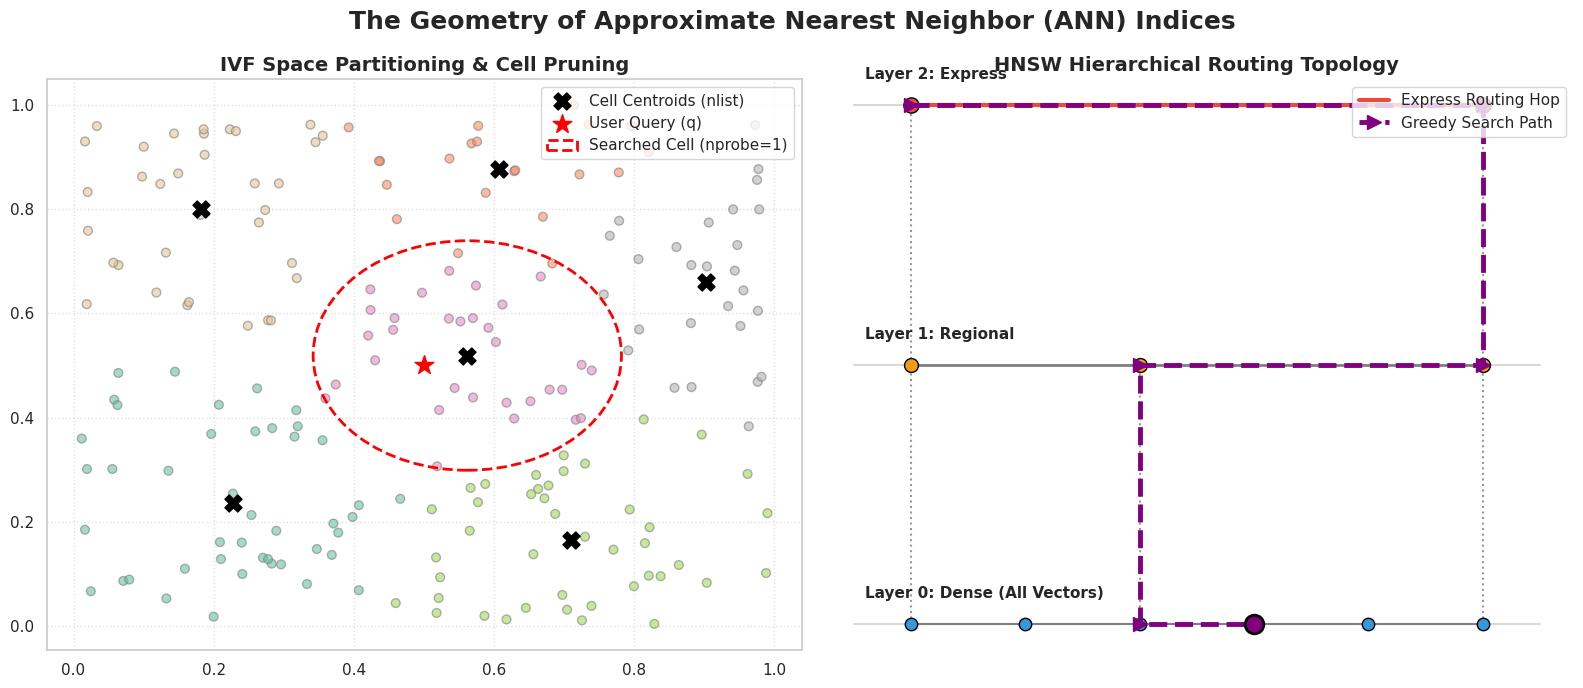


--- 💡 Engineering Insight ---
Look at the Left Chart: By locking nprobe=1, the system only opens the single bucket outlined in the red dashed line. It completely ignores the other 5 clusters, protecting search speed. If the true best match sits just outside that red circle, accuracy drops—this is the fundamental engineering trade-off of vector indexing.
Look at the Right Chart: The search enters at the top express tier, makes a wide spatial leap across the space, and then drops vertically down through the levels to perform local fine-grained structural crawling once it gets close to the target coordinates.


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("The Geometry of Approximate Nearest Neighbor (ANN) Indices", fontsize=18, fontweight='bold')

# --- Left Panel: IVF Voronoi Cell Space Pruning ---
np.random.seed(0)
points = np.random.rand(200, 2)
kmeans_viz = KMeans(n_clusters=6, random_state=0, n_init=10).fit(points)
centroids_viz = kmeans_viz.cluster_centers_

# Scatter points colored by their structural cell assignments
ax1.scatter(points[:, 0], points[:, 1], c=kmeans_viz.labels_, cmap='Set2', s=40, alpha=0.6, edgecolors='gray')
ax1.scatter(centroids_viz[:, 0], centroids_viz[:, 1], c='black', s=150, marker='X', label='Cell Centroids (nlist)')

# Highlight a sample query and its local pruning radius
query_pt = np.array([0.5, 0.5])
ax1.scatter(query_pt[0], query_pt[1], c='red', s=200, marker='*', zorder=5, label='User Query (q)')

# Circle the closest cell to represent nprobe=1
closest_centroid = centroids_viz[np.argmin(np.linalg.norm(centroids_viz - query_pt, axis=1))]
circle = plt.Circle((closest_centroid[0], closest_centroid[1]), 0.22, color='red', fill=False, linestyle='--', linewidth=2, label='Searched Cell (nprobe=1)')
ax1.add_patch(circle)

ax1.set_title("IVF Space Partitioning & Cell Pruning", fontsize=14, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Right Panel: HNSW Multi-Layer Skip-Graph Traversal ---
ax2.axis('off')
ax2.set_title("HNSW Hierarchical Routing Topology", fontsize=14, fontweight='bold')

# Define coordinates for layered visualization nodes
layer_heights = [2.5, 1.5, 0.5] # Express, Regional, Local Layers
layer_labels = ["Layer 2: Express", "Layer 1: Regional", "Layer 0: Dense (All Vectors)"]
node_x_coords = [2, 4, 6, 8, 10, 12]

# Draw horizontal alignment lanes representing graph layers
for h, label in zip(layer_heights, layer_labels):
    ax2.plot([1, 13], [h, h], color='gray', linestyle='-', alpha=0.3)
    ax2.text(1.2, h + 0.1, label, fontsize=11, fontweight='bold')

# Plot structural nodes across the layers
# Layer 2 Nodes
ax2.scatter([2, 12], [2.5, 2.5], color='#e74c3c', s=120, edgecolors='black', zorder=3)
ax2.plot([2, 12], [2.5, 2.5], color='#e74c3c', linewidth=3, linestyle='-', label='Express Routing Hop')

# Layer 1 Nodes
ax2.scatter([2, 6, 12], [1.5, 1.5, 1.5], color='#f39c12', s=100, edgecolors='black', zorder=3)
ax2.plot([2, 6, 12], [1.5, 1.5, 1.5], color='gray', linewidth=2, linestyle='-')

# Layer 0 Nodes
ax2.scatter(node_x_coords, [0.5]*6, color='#3498db', s=80, edgecolors='black', zorder=3)
ax2.plot(node_x_coords, [0.5]*6, color='gray', linewidth=1.5, linestyle='-')

# Draw vertical structural links connecting corresponding nodes across tiers
for x in [2, 12]:
    ax2.plot([x, x], [0.5, 2.5], color='black', linestyle=':', alpha=0.4)
ax2.plot([6, 6], [0.5, 1.5], color='black', linestyle=':', alpha=0.4)

# Trace an animated query routing vector path down through the structure
path_x = [2, 12, 12, 6, 6, 8]
path_y = [2.5, 2.5, 1.5, 1.5, 0.5, 0.5]
ax2.plot(path_x, path_y, color='purple', linewidth=3.5, linestyle='--', marker='>', markersize=10, zorder=4, label='Greedy Search Path')

# Mark target node destination
ax2.scatter([8], [0.5], color='purple', s=180, marker='o', edgecolors='black', linewidths=2, zorder=5)

ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

print("\n--- 💡 Engineering Insight ---")
print("Look at the Left Chart: By locking nprobe=1, the system only opens the single bucket outlined in the red dashed line. It completely ignores the other 5 clusters, protecting search speed. If the true best match sits just outside that red circle, accuracy drops—this is the fundamental engineering trade-off of vector indexing.")
print("Look at the Right Chart: The search enters at the top express tier, makes a wide spatial leap across the space, and then drops vertically down through the levels to perform local fine-grained structural crawling once it gets close to the target coordinates.")

## Real-World Use Case or Analogy:

### The IVF Index Analogy: Finding a Book in a Multi-Campus Library

Imagine you are looking for an obscure textbook inside a massive university network containing 10 million books.

* **Brute Force Search:** You start at Shelf 1 of Library 1 and read every single book spine one by one until you reach book number 10,000,000. You will find your book, but it will take months.
* **IVF Indexing (`nlist=50`):** The university categorizes the 10 million books into 50 distinct thematic campuses (e.g., Medicine, Fine Arts, Aerospace Engine Design).
* **The Tuning Knob (`nprobe=2`):** When you search for a book on rocket propulsion, you check the campus directory. You locate the two closest subject matches (`nprobe=2`): Aerospace and Mechanical Engineering. You fly directly to those two specific campuses and search *only* their local shelves. You ignore the remaining 48 campuses completely, cutting out 96% of the work.

### The HNSW Index Analogy: Express vs. Local Subway Transit

Imagine you want to travel from a small, local street corner on the outer edge of New York City to a precise residential address on the opposite end of the metro area.

* **Layer 2 (Express Lines):** You board an inter-city bullet train that moves at incredible speeds across the map but makes only two stops: Downtown and Uptown. You use this network to make massive, sweeping spatial advancements across the region.
* **Layer 1 (Regional Lines):** Once you arrive at the broad regional terminal closest to your destination, you step off the express train, move down to the lower platform, and board a regional subway line that stops at major neighborhood hubs.
* **Layer 0 (Local Streets):** Finally, you exit the subway stairs onto the street layer where every block contains a house number. You walk block by block to find the exact target doorway. You navigate millions of possible locations in minutes by using high-level networks to bypass the local details until the last possible mile.